In [1]:
# Import necessary functions
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('meningitis_dataset.csv')
df


,id,surname,firstname,middlename,gender,gender_male,gender_female,state,settlement,rural_settlement,...,NmA,NmC,NmW,health_status,alive,dead,report_outcome,unconfirmed,confirmed,null_serotype
0,1,Solade,Grace,Solape,Female,0,1,Rivers,Rural,1,...,0,0,0,alive,1,0,confirmed,0,1,1
1,2,Eneche,Kure,Balogun,Male,1,0,Ebonyi,Rural,1,...,0,0,1,Alive,1,0,Confirmed,1,0,1
2,3,Sanusi,Adaugo,Katerine,Female,0,1,Ogun,Urban,0,...,0,0,1,Dead,0,1,Not Confirmed,1,0,1
3,4,Sowore,Mooslemat,Ifedayo,Female,0,1,Ondo,Rural,1,...,0,0,1,Alive,1,0,Not Confirmed,1,0,1
4,5,Abdusalam,Yusuf,Okafor,Male,1,0,Oyo,Urban,0,...,0,0,1,Alive,1,0,Confirmed,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284479,288418,Mukthar,Alimat,Ajibewa,Female,0,1,Cross River,Rural,1,...,0,0,1,Dead,0,1,Confirmed,1,0,1
284480,288419,Akenzua,Deborah,Rofeeqat,Female,0,1,Kwara,Urban,0,...,0,0,1,Dead,0,1,Confirmed,1,0,1
284481,288420,Isa,Deborah,Tofunmi,Female,0,1,Katsina,Rural,1,...,0,0,1,Alive,1,0,Confirmed,0,1,1
284482,288421,Uba,Ismail,Akpabio,Male,1,0,Jigawa,Rural,1,...,0,0,1,Dead,0,1,Not Confirmed,1,0,1


In [2]:
print(df.columns)


Index(['id', 'surname', 'firstname', 'middlename', 'gender', 'gender_male',
       'gender_female', 'state', 'settlement', 'rural_settlement',
       'urban_settlement', 'report_date', 'report_year', 'age', 'age_str',
       'date_of_birth', 'child_group', 'adult_group', 'disease', 'cholera',
       'diarrhoea', 'measles', 'viral_haemmorrhaphic_fever', 'meningitis',
       'ebola', 'marburg_virus', 'yellow_fever', 'rubella_mars', 'malaria',
       'serotype', 'NmA', 'NmC', 'NmW', 'health_status', 'alive', 'dead',
       'report_outcome', 'unconfirmed', 'confirmed', 'null_serotype'],
      dtype='object')


In [3]:
df.shape #Check the number of rows and columns in the dataset

(284484, 40)

In [4]:
#print the sum of null values in the dataset
df.isna().sum()

,0
id,0
surname,0
firstname,0
middlename,0
gender,0
gender_male,0
gender_female,0
state,0
settlement,0
rural_settlement,0


In [6]:
#Check for duplicated values
print(df.duplicated().sum())

0


In [7]:
# Standardize text columns to small letters
df["health_status"] = df["health_status"].str.lower()
df["report_outcome"] = df["report_outcome"].str.lower()

In [8]:
#Transform the date column to datetime
df["report_date"] = pd.to_datetime(df["report_date"], errors="coerce")


Keep only the necessary columns and get rid of the rest to make work easier

In [9]:
#Only keep the columns relevant
df_cleaned = df[["gender", "age", "report_year", "settlement", "cholera", "health_status", "report_outcome", "state", "report_date", "diarrhoea", "measles", "viral_haemmorrhaphic_fever", "meningitis", "ebola", "marburg_virus", "yellow_fever", "rubella_mars", "malaria"]]

# Filter for cholera cases
cholera_cases = df_cleaned[df_cleaned["cholera"] == 1]
diarrhoea_cases = df_cleaned[df_cleaned["diarrhoea"] == 1]
measles_cases = df_cleaned[df_cleaned["measles"] == 1]
viral_haemmorrhaphic_fever_cases = df_cleaned[df_cleaned["viral_haemmorrhaphic_fever"] == 1]
meningitis_cases = df_cleaned[df_cleaned["meningitis"] == 1]
ebola_cases = df_cleaned[df_cleaned["ebola"] == 1]
marburg_virus_cases = df_cleaned[df_cleaned["marburg_virus"] ==1]
yellow_fever_cases = df_cleaned[df_cleaned["yellow_fever"] ==1]
rubella_mars_cases = df_cleaned[df_cleaned['rubella_mars'] ==1]
malaria_cases = df_cleaned[df_cleaned["malaria"] == 1]

Calculate the total number of cases recorded per illness

In [10]:
mengi_counts = meningitis_cases["meningitis"].value_counts()# total for meningitis
print(mengi_counts)

meningitis
1    28362
Name: count, dtype: int64


In [11]:
# List of illness columns
illness_columns = ["cholera", "meningitis", "diarrhoea", "measles", "viral_haemmorrhaphic_fever", "ebola", "marburg_virus", "yellow_fever", "rubella_mars", "malaria"]

# Count cases for each illness
illness_counts = df_cleaned[illness_columns].sum()

# Display results
print("Total Cases Per Illness:\n", illness_counts)


Total Cases Per Illness:
 cholera                       28589
meningitis                    28362
diarrhoea                     28550
measles                       28471
viral_haemmorrhaphic_fever    28401
ebola                         28179
marburg_virus                 28430
yellow_fever                  28428
rubella_mars                  28539
malaria                       28535
dtype: int64


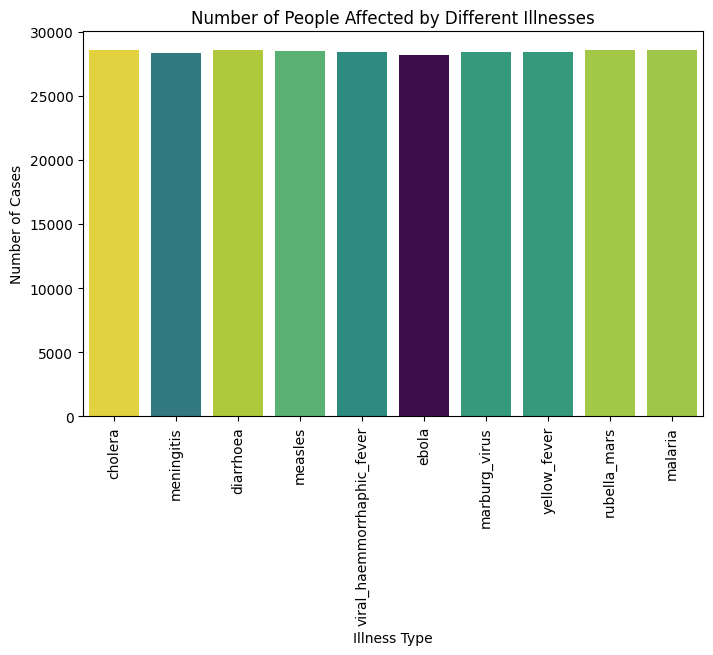

In [12]:
# Plot illness counts
plt.figure(figsize=(8, 5))
sns.barplot(x=illness_counts.index, y=illness_counts.values, hue= illness_counts, palette="viridis", legend=False)
plt.title("Number of People Affected by Different Illnesses")
plt.xlabel("Illness Type")
plt.xticks(rotation=90)
plt.ylabel("Number of Cases")
plt.show()

In [13]:
# Define illness columns (excluding meningitis)
other_illnesses = ["cholera", "diarrhoea", "measles", "viral_haemmorrhaphic_fever", "ebola", "marburg_virus", "yellow_fever", "rubella_mars", "malaria"]
# Filter cases where meningitis is 1 and at least one other illness is also 1
meningitis_and_other_illnesses = df_cleaned[
    (df_cleaned["meningitis"] == 1) & (df_cleaned[other_illnesses].sum(axis=1) > 0)
]

# Display first few rows
print(meningitis_and_other_illnesses.head())


Empty DataFrame
Columns: [gender, age, report_year, settlement, cholera, health_status, report_outcome, state, report_date, diarrhoea, measles, viral_haemmorrhaphic_fever, meningitis, ebola, marburg_virus, yellow_fever, rubella_mars, malaria]
Index: []


In [14]:
total_cases = len(meningitis_and_other_illnesses)
print(f"Total people with Meningitis + another illness: {total_cases}")


Total people with Meningitis + another illness: 0


There are no cases recorded of people suffering from Meningitis as well as any other illness at the same time

In [15]:
# Count the number of affected males and females
gender_counts = meningitis_cases["gender"].value_counts()
print(gender_counts)


gender
Female    14691
Male      13671
Name: count, dtype: int64


In [16]:
#Spread of Meningitis per State
states_with_meningitis = meningitis_cases["state"].value_counts()
states_with_meningitis

,count
state,
Benue,849
Ebonyi,822
Federal Capital Territory,797
Imo,795
Niger,793
Kebbi,789
Anambra,789
Ogun,789
Kaduna,783


In [17]:
# Count meningitis cases per state and get the top affected state
top_state = meningitis_cases["state"].value_counts().idxmax()
top_state_cases = meningitis_cases["state"].value_counts().max()

print(f"State with the highest meningitis cases: {top_state} ({top_state_cases} cases)")


State with the highest meningitis cases: Benue (849 cases)


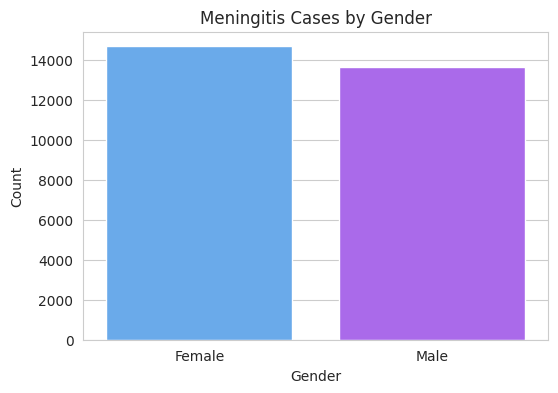

In [18]:
# Set Seaborn style of choice
sns.set_style("whitegrid")

# 1. Gender distribution of Meningitis cases
plt.figure(figsize=(6, 4))
sns.countplot(data=meningitis_cases, x="gender", hue="gender", palette="cool", legend = False)
plt.title("Meningitis Cases by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

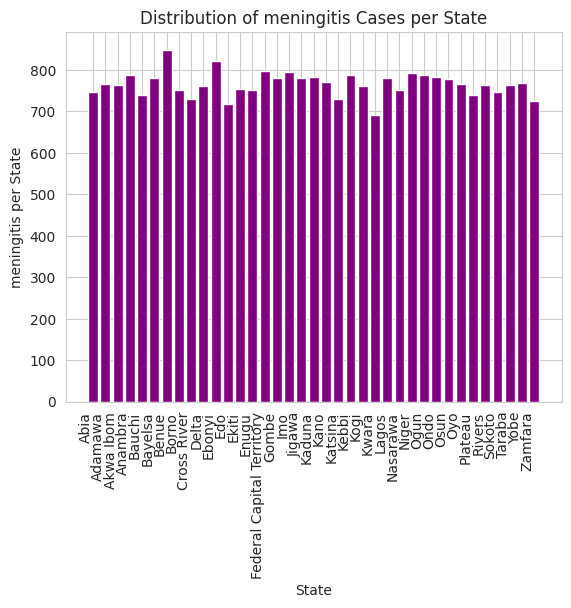

In [19]:
#Bar plot for meningitis in each state
meningitis_per_state = df.groupby('state')['meningitis'].sum().reset_index()

plt.bar(meningitis_per_state['state'], meningitis_per_state['meningitis'], color = 'purple')
plt.xlabel('State')
plt.ylabel('meningitis per State')
plt.title('Distribution of meningitis Cases per State')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better visibility
plt.show()

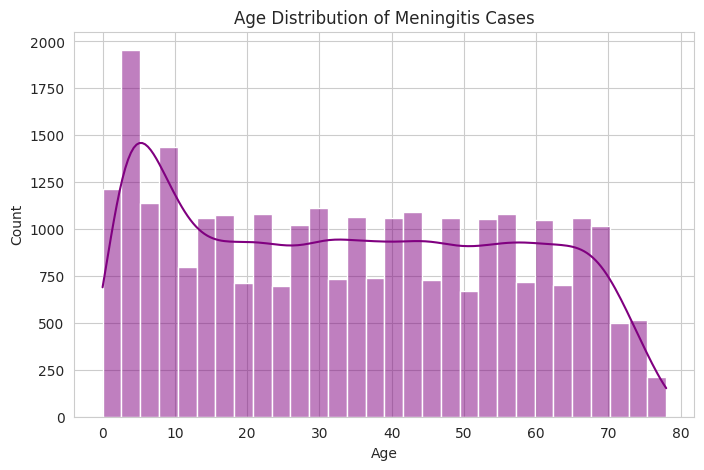

In [20]:
# Age distribution of Meningitis cases
plt.figure(figsize=(8, 5))
sns.histplot(meningitis_cases["age"], bins=30, kde=True, color="purple")
plt.title("Age Distribution of Meningitis Cases")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

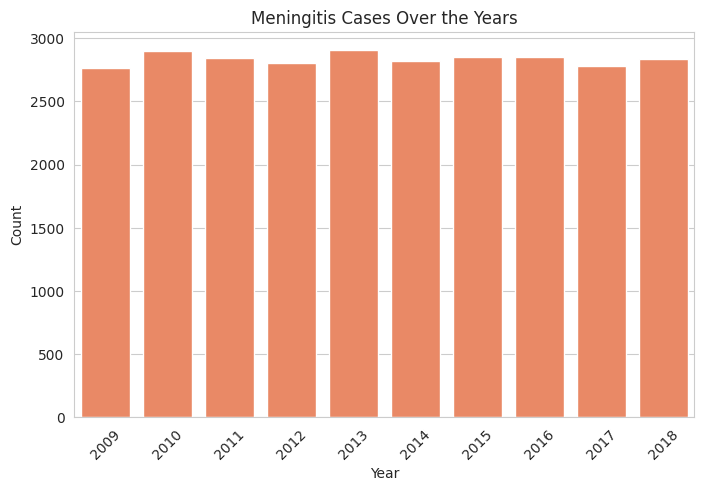

In [21]:
#Meningitis cases trend over the years
plt.figure(figsize=(8, 5))
sns.countplot(data=meningitis_cases, x="report_year", color="coral")
plt.xticks(rotation=45)
plt.title("Meningitis Cases Over the Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


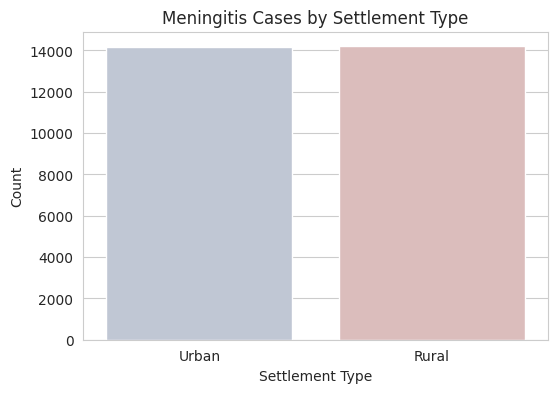

In [22]:
# Urban vs. Rural impact of Meningitis
plt.figure(figsize=(6, 4))
sns.countplot(data=meningitis_cases, x="settlement", hue="settlement", palette="vlag", legend=False)
plt.title("Meningitis Cases by Settlement Type")
plt.xlabel("Settlement Type")
plt.ylabel("Count")
plt.show()

In [23]:
# Mortality rate among Meningitis cases
meningitis_deaths = meningitis_cases[meningitis_cases["health_status"] == "dead"]
mortality_rate = (len(meningitis_deaths) / len(meningitis_cases)) * 100

print(f"Meningitis Mortality Rate: {mortality_rate:.2f}%")


Meningitis Mortality Rate: 49.99%


In [24]:
Meningitis_per_agegroup = meningitis_cases["age"].value_counts()
Meningitis_per_agegroup

,count
age,
2,755
3,677
4,642
5,635
6,598
...,...
75,137
76,117
77,68


In [25]:
age_with_highest= meningitis_cases["age"].value_counts().idxmax()
highest_cases = meningitis_cases["age"].value_counts().max()

print(f"Age with the highest Meningitis cases: {age_with_highest} ({highest_cases} cases)")


Age with the highest Meningitis cases: 2 (755 cases)


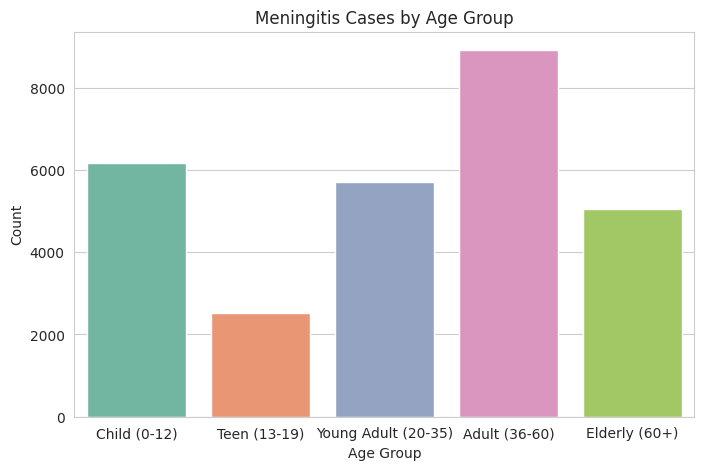

In [26]:
meningitis_cases = meningitis_cases.copy()
# Define age groups
bins = [0, 12, 19, 35, 60, 100]  # Age brackets
labels = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-35)", "Adult (36-60)", "Elderly (60+)"]
meningitis_cases.loc[:, "age_group"] = pd.cut(meningitis_cases["age"], bins=bins, labels=labels, right=False)

# Countplot of age groups
plt.figure(figsize=(8, 5))
sns.countplot(data=meningitis_cases, x="age_group", hue= "age_group", palette="Set2", legend=False)
plt.title("Meningitis Cases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()


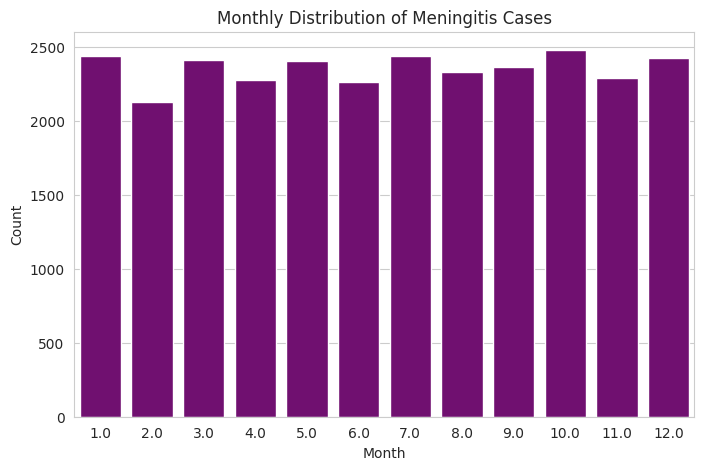

In [27]:
# Extract month from report_date
meningitis_cases.loc[:, "report_month"] = meningitis_cases["report_date"].dt.month

# Plot cases per month
plt.figure(figsize=(8, 5))
sns.countplot(data=meningitis_cases, x="report_month", color="purple")
plt.title("Monthly Distribution of Meningitis Cases")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


In [28]:
C_report_month= meningitis_cases["report_month"].value_counts()
C_report_month

,count
report_month,
10.0,2477
1.0,2436
7.0,2435
12.0,2424
3.0,2413
5.0,2401
9.0,2363
8.0,2329
11.0,2285


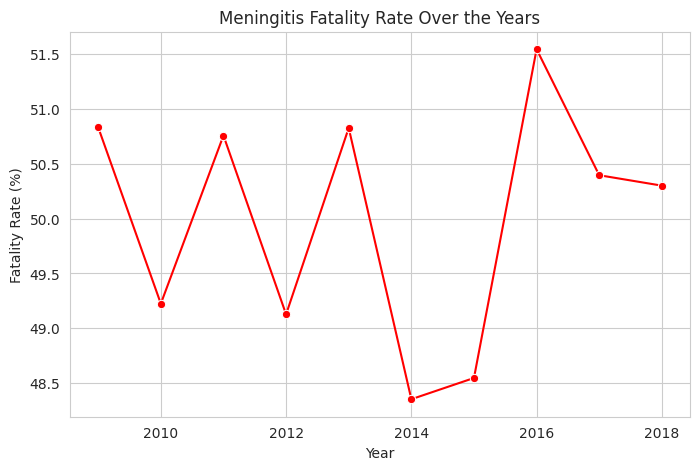

In [29]:
# Death rate by year
meningitis_yearly = meningitis_cases.groupby("report_year").agg(
    total_cases=("meningitis", "count"),
    deaths=("health_status", lambda x: (x == "dead").sum())
)

meningitis_yearly["death_rate"] = (meningitis_yearly["deaths"] / meningitis_yearly["total_cases"]) * 100

# Plot
plt.figure(figsize=(8, 5))
sns.lineplot(data=meningitis_yearly, x=meningitis_yearly.index, y="death_rate", marker="o", color="red")
plt.title("Meningitis Fatality Rate Over the Years")
plt.xlabel("Year")
plt.ylabel("Fatality Rate (%)")
plt.show()


In [30]:
# Convert categorical variables to one-hot encoding
df_cleaned = pd.get_dummies(df_cleaned, columns=["state", "gender", "settlement", "health_status", "report_outcome"], drop_first=True)

# Check new columns
print(df_cleaned.head())


   age  report_year  cholera report_date  diarrhoea  measles  \
0   32         2018        1  2018-05-15          0        0   
1   32         2017        0  2017-02-28          0        0   
2   24         2012        0  2012-03-02          0        0   
3   63         2010        0  2010-05-21          0        1   
4    9         2017        0  2017-08-28          0        0   

   viral_haemmorrhaphic_fever  meningitis  ebola  marburg_virus  ...  \
0                           0           0      0              0  ...   
1                           0           0      0              1  ...   
2                           0           0      0              1  ...   
3                           0           0      0              0  ...   
4                           0           0      0              0  ...   

   state_Plateau  state_Rivers  state_Sokoto  state_Taraba  state_Yobe  \
0          False          True         False         False       False   
1          False         False    

In [31]:
# Compute correlation matrix
correlation_matrix = df_cleaned.corr()

# Display correlation values for meningitis
print(correlation_matrix["meningitis"].sort_values(ascending=False))

meningitis                         1.000000
state_Benue                        0.005308
state_Ebonyi                       0.003579
state_Federal Capital Territory    0.002394
state_Ogun                         0.001828
state_Anambra                      0.001470
state_Imo                          0.001371
state_Lagos                        0.001336
state_Gombe                        0.001205
state_Kebbi                        0.001077
state_Jigawa                       0.000863
state_Taraba                       0.000824
state_Niger                        0.000801
report_outcome_not confirmed       0.000792
state_Kaduna                       0.000717
state_Osun                         0.000559
settlement_Urban                   0.000376
state_Bayelsa                      0.000335
state_Akwa Ibom                    0.000306
state_Ondo                         0.000135
state_Rivers                       0.000081
state_Adamawa                      0.000039
state_Ekiti                     